# RESULTS

In this file we are going to evaluate the results. We will start by checking the performance of each group of features regarding the predictions we achieve with all the combinations of them, and looking at what metrics each grup increases. Based on that we will define our final group of features, so our final model.

The last step will consist on evaluate this model by checking the feature importance, the shap values and finally showing some examples of the performance of the model, and the general performance in both the hard onset countries and the protracted ones. 

In [1]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, precision_recall_curve, f1_score, roc_auc_score, average_precision_score, precision_score, recall_score, confusion_matrix
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from panelsplit.cross_validation import PanelSplit
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import ipywidgets as widgets

In [2]:
# Define the exact path where the file was saved
file_path = "results/experiments_map.json"

# Open the file in read mode ('r') and load it
with open(file_path, "r", encoding="utf-8") as f:
    experiments_map = json.load(f)

experiments_map["Random Benchmark (Stratified)"] = "benchmark_random"
experiments_map["Optimal"] = "optimal"

# Perfect! Your dictionary is now fully recovered
print(f"Experiments map loaded successfully. Total experiments: {len(experiments_map)}")

Experiments map loaded successfully. Total experiments: 73


### 1. RESULTS ANALYSIS BASED ON FEATURES GROUPS

In [3]:
def evaluate_experiments(plots_filter, df_master, threshold_05=False, results_folder="results", experiments_map=None):
    """
    Evaluates ML experiments, plots 6 curves (Global, Protracted, Hard Onset),
    calculates subgroup metrics, and displays ONE single global legend at the bottom without overlapping.
    """
    comparison_results = []
    
    # Prepare the graphics
    fig, axes = plt.subplots(3, 2, figsize=(18, 35))
    ax_roc_glob, ax_pr_glob = axes[0]
    ax_roc_pro, ax_pr_pro = axes[1]
    ax_roc_hard, ax_pr_hard = axes[2]

    for name, prefix in experiments_map.items():
        if name not in plots_filter:
            continue

        pred_file = os.path.join(results_folder, f"{prefix}_predictions.csv")
        feat_file = os.path.join(results_folder, f"{prefix}_feature_importance.csv")
        
        if not os.path.exists(pred_file):
            continue
            
        print(f"Processing: {name}...")
        
        # Load predictions
        df_preds = pd.read_csv(pred_file)

        if 'Unnamed: 0' in df_preds.columns and 'Unnamed: 1' in df_preds.columns:
            df_preds = df_preds.rename(columns={'Unnamed: 0': 'iso3', 'Unnamed: 1': 'month'})
        
        if 'month' in df_preds.columns:
            df_preds['month'] = pd.to_datetime(df_preds['month'], errors='coerce')

        all_y_true = df_preds["y_true"]
        all_y_prob = df_preds["y_prob"]

        # Optimize threshold based on F1 score if not using 0.5
        if threshold_05:
            current_threshold = 0.5
        else:
            precisions, recalls, thresholds_pr = precision_recall_curve(all_y_true, all_y_prob)
            f1_scores = np.divide(
                2 * (precisions * recalls),
                (precisions + recalls),
                out=np.zeros_like(precisions),
                where=(precisions + recalls) != 0
            )
            best_idx = np.argmax(f1_scores[:-1])
            current_threshold = thresholds_pr[best_idx]

        df_preds['y_pred'] = (all_y_prob >= current_threshold).astype(int)

        # Global metrics
        f1 = f1_score(all_y_true, df_preds['y_pred'])
        prec = precision_score(all_y_true, df_preds['y_pred'], zero_division=0)
        rec = recall_score(all_y_true, df_preds['y_pred'])
        roc_auc = roc_auc_score(all_y_true, all_y_prob)
        num_features = len(pd.read_csv(feat_file)) if os.path.exists(feat_file) else 0

        # Subgroup metrics initialization
        pro_prec, pro_rec, pro_f1, pro_roc_auc = np.nan, np.nan, np.nan, np.nan
        hard_prec, hard_rec, hard_f1, hard_roc_auc = np.nan, np.nan, np.nan, np.nan
        has_subgroups = False
        
        if 'is_protracted' not in df_preds.columns:
            if 'iso3' in df_preds.columns and 'month' in df_preds.columns:
                df_preds = pd.merge(df_preds, df_master[['iso3', 'month', 'is_protracted']], on=['iso3', 'month'], how='inner')

        if 'is_protracted' in df_preds.columns and not df_preds['is_protracted'].isna().all():
            has_subgroups = True
        
        # Plotting ROC and PR curves
        fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
        ax_roc_glob.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
        
        prec_curve, rec_curve, _ = precision_recall_curve(all_y_true, all_y_prob)
        avg_prec = average_precision_score(all_y_true, all_y_prob)
        ax_pr_glob.plot(rec_curve, prec_curve, lw=2, label=f'{name} (AP = {avg_prec:.3f})')

        if has_subgroups:
            # Protracted crises
            pro_mask = df_preds['is_protracted'] == 1
            if pro_mask.sum() > 0:
                y_t_pro = df_preds.loc[pro_mask, 'y_true']
                y_p_pro = df_preds.loc[pro_mask, 'y_prob']
                y_pred_pro = df_preds.loc[pro_mask, 'y_pred']
                
                pro_prec = precision_score(y_t_pro, y_pred_pro, zero_division=0)
                pro_rec = recall_score(y_t_pro, y_pred_pro, zero_division=0)
                pro_f1 = f1_score(y_t_pro, y_pred_pro, zero_division=0)
                
                if len(np.unique(y_t_pro)) > 1:
                    pro_roc_auc = roc_auc_score(y_t_pro, y_p_pro)
                    fpr_p, tpr_p, _ = roc_curve(y_t_pro, y_p_pro)
                    ax_roc_pro.plot(fpr_p, tpr_p, lw=2) 
                    
                    prec_p, rec_p, _ = precision_recall_curve(y_t_pro, y_p_pro)
                    ax_pr_pro.plot(rec_p, prec_p, lw=2)

            # Hard onset crises
            hard_mask = df_preds['is_protracted'] == 0
            if hard_mask.sum() > 0:
                y_t_hard = df_preds.loc[hard_mask, 'y_true']
                y_p_hard = df_preds.loc[hard_mask, 'y_prob']
                y_pred_hard = df_preds.loc[hard_mask, 'y_pred']
                
                hard_prec = precision_score(y_t_hard, y_pred_hard, zero_division=0)
                hard_rec = recall_score(y_t_hard, y_pred_hard, zero_division=0)
                hard_f1 = f1_score(y_t_hard, y_pred_hard, zero_division=0)
                
                if len(np.unique(y_t_hard)) > 1:
                    hard_roc_auc = roc_auc_score(y_t_hard, y_p_hard)
                    fpr_h, tpr_h, _ = roc_curve(y_t_hard, y_p_hard)
                    ax_roc_hard.plot(fpr_h, tpr_h, lw=2)
                    
                    prec_h, rec_h, _ = precision_recall_curve(y_t_hard, y_p_hard)
                    ax_pr_hard.plot(rec_h, prec_h, lw=2)

        # Save results for comparison
        comparison_results.append({
            'Experiment': name,
            'Thr': round(current_threshold, 3),
            'Glob F1': round(f1, 3),
            'Glob P': round(prec, 3),
            'Glob R': round(rec, 3),
            'Glob AUC': round(roc_auc, 3),
            'Pro F1': round(pro_f1, 3) if pd.notna(pro_f1) else '-',
            'Pro P': round(pro_prec, 3) if pd.notna(pro_prec) else '-',
            'Pro R': round(pro_rec, 3) if pd.notna(pro_rec) else '-',
            'Pro AUC': round(pro_roc_auc, 3) if pd.notna(pro_roc_auc) else '-',
            'Hard F1': round(hard_f1, 3) if pd.notna(hard_f1) else '-',
            'Hard P': round(hard_prec, 3) if pd.notna(hard_prec) else '-',
            'Hard R': round(hard_rec, 3) if pd.notna(hard_rec) else '-',
            'Hard AUC': round(hard_roc_auc, 3) if pd.notna(hard_roc_auc) else '-',
            'Feats': num_features
        })


    plot_configs = [
        (ax_roc_glob, ax_pr_glob, 'GLOBAL'),
        (ax_roc_pro, ax_pr_pro, 'PROTRACTED CRISES (is_protracted = 1)'),
        (ax_roc_hard, ax_pr_hard, 'HARD ONSET CRISES (is_protracted = 0)')
    ]
    
    for ax_roc, ax_pr, title in plot_configs:
        ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_title(f'{title}: ROC Curve', fontsize=14, fontweight='bold')
        ax_roc.set_xlabel('False Positive Rate', fontsize=11)
        ax_roc.set_ylabel('True Positive Rate', fontsize=11)
        ax_roc.grid(alpha=0.3)

        ax_pr.set_xlim([0.0, 1.0])
        ax_pr.set_ylim([0.0, 1.05])
        ax_pr.set_title(f'{title}: Precision-Recall Curve', fontsize=14, fontweight='bold')
        ax_pr.set_xlabel('Recall', fontsize=11)
        ax_pr.set_ylabel('Precision', fontsize=11)
        ax_pr.grid(alpha=0.3)

    handles, labels = ax_roc_glob.get_legend_handles_labels()
    
    plt.tight_layout(rect=[0, 0.25, 1, 1])
    
    fig.legend(
        handles, 
        labels, 
        loc='upper center',       
        bbox_to_anchor=(0.5, 0.23),
        ncol=3,                  
        fontsize=9, 
        frameon=True,
        facecolor='#f9f9f9',
        edgecolor='#d3d3d3'
    )

    plt.show()

    # Print final ranking of experiments based on Global F1 score
    if comparison_results:
        df_results = pd.DataFrame(comparison_results).sort_values(by='Glob F1', ascending=False)
        print("\n" + "#"*160)
        print("FINAL RANKING (SORTED BY GLOBAL F1)".center(160))
        print("#"*160)
        print(df_results.to_string(index=False))
    else:
        print("\nNo experiments were successfully loaded.")

All the available models that we have, and that we can check their performance are:

In [4]:
models = list(experiments_map.keys())

In [5]:
print(models)

['Only Signals (CERF)', 'Only INFORM', 'Only INFORM + Only Signals (CERF)', 'Only Risk Alerts', 'Only Risk Alerts + Only Signals (CERF)', 'Only Risk Alerts + Only INFORM', 'Only Risk Alerts + Only INFORM + Only Signals (CERF)', 'Only Risk Alerts BEST', 'Only Risk Alerts BEST + Only Signals (CERF)', 'Only Risk Alerts BEST + Only INFORM', 'Only Risk Alerts BEST + Only INFORM + Only Signals (CERF)', 'Derived Humanitarian Impact', 'Derived Humanitarian Impact + Only Signals (CERF)', 'Derived Humanitarian Impact + Only INFORM', 'Derived Humanitarian Impact + Only INFORM + Only Signals (CERF)', 'Derived Humanitarian Impact + Only Risk Alerts', 'Derived Humanitarian Impact + Only Risk Alerts + Only Signals (CERF)', 'Derived Humanitarian Impact + Only Risk Alerts + Only INFORM', 'Derived Humanitarian Impact + Only Risk Alerts + Only INFORM + Only Signals (CERF)', 'Derived Humanitarian Impact + Only Risk Alerts BEST', 'Derived Humanitarian Impact + Only Risk Alerts BEST + Only Signals (CERF)', 

Plotting the comparison of all the possible combinations:

Processing: Only Signals (CERF)...
Processing: Only INFORM...
Processing: Only INFORM + Only Signals (CERF)...
Processing: Only Risk Alerts...
Processing: Only Risk Alerts + Only Signals (CERF)...
Processing: Only Risk Alerts + Only INFORM...
Processing: Only Risk Alerts + Only INFORM + Only Signals (CERF)...
Processing: Only Risk Alerts BEST...
Processing: Only Risk Alerts BEST + Only Signals (CERF)...
Processing: Only Risk Alerts BEST + Only INFORM...
Processing: Only Risk Alerts BEST + Only INFORM + Only Signals (CERF)...
Processing: Derived Humanitarian Impact...
Processing: Derived Humanitarian Impact + Only Signals (CERF)...
Processing: Derived Humanitarian Impact + Only INFORM...
Processing: Derived Humanitarian Impact + Only INFORM + Only Signals (CERF)...
Processing: Derived Humanitarian Impact + Only Risk Alerts...
Processing: Derived Humanitarian Impact + Only Risk Alerts + Only Signals (CERF)...
Processing: Derived Humanitarian Impact + Only Risk Alerts + Only INFORM...
Pro

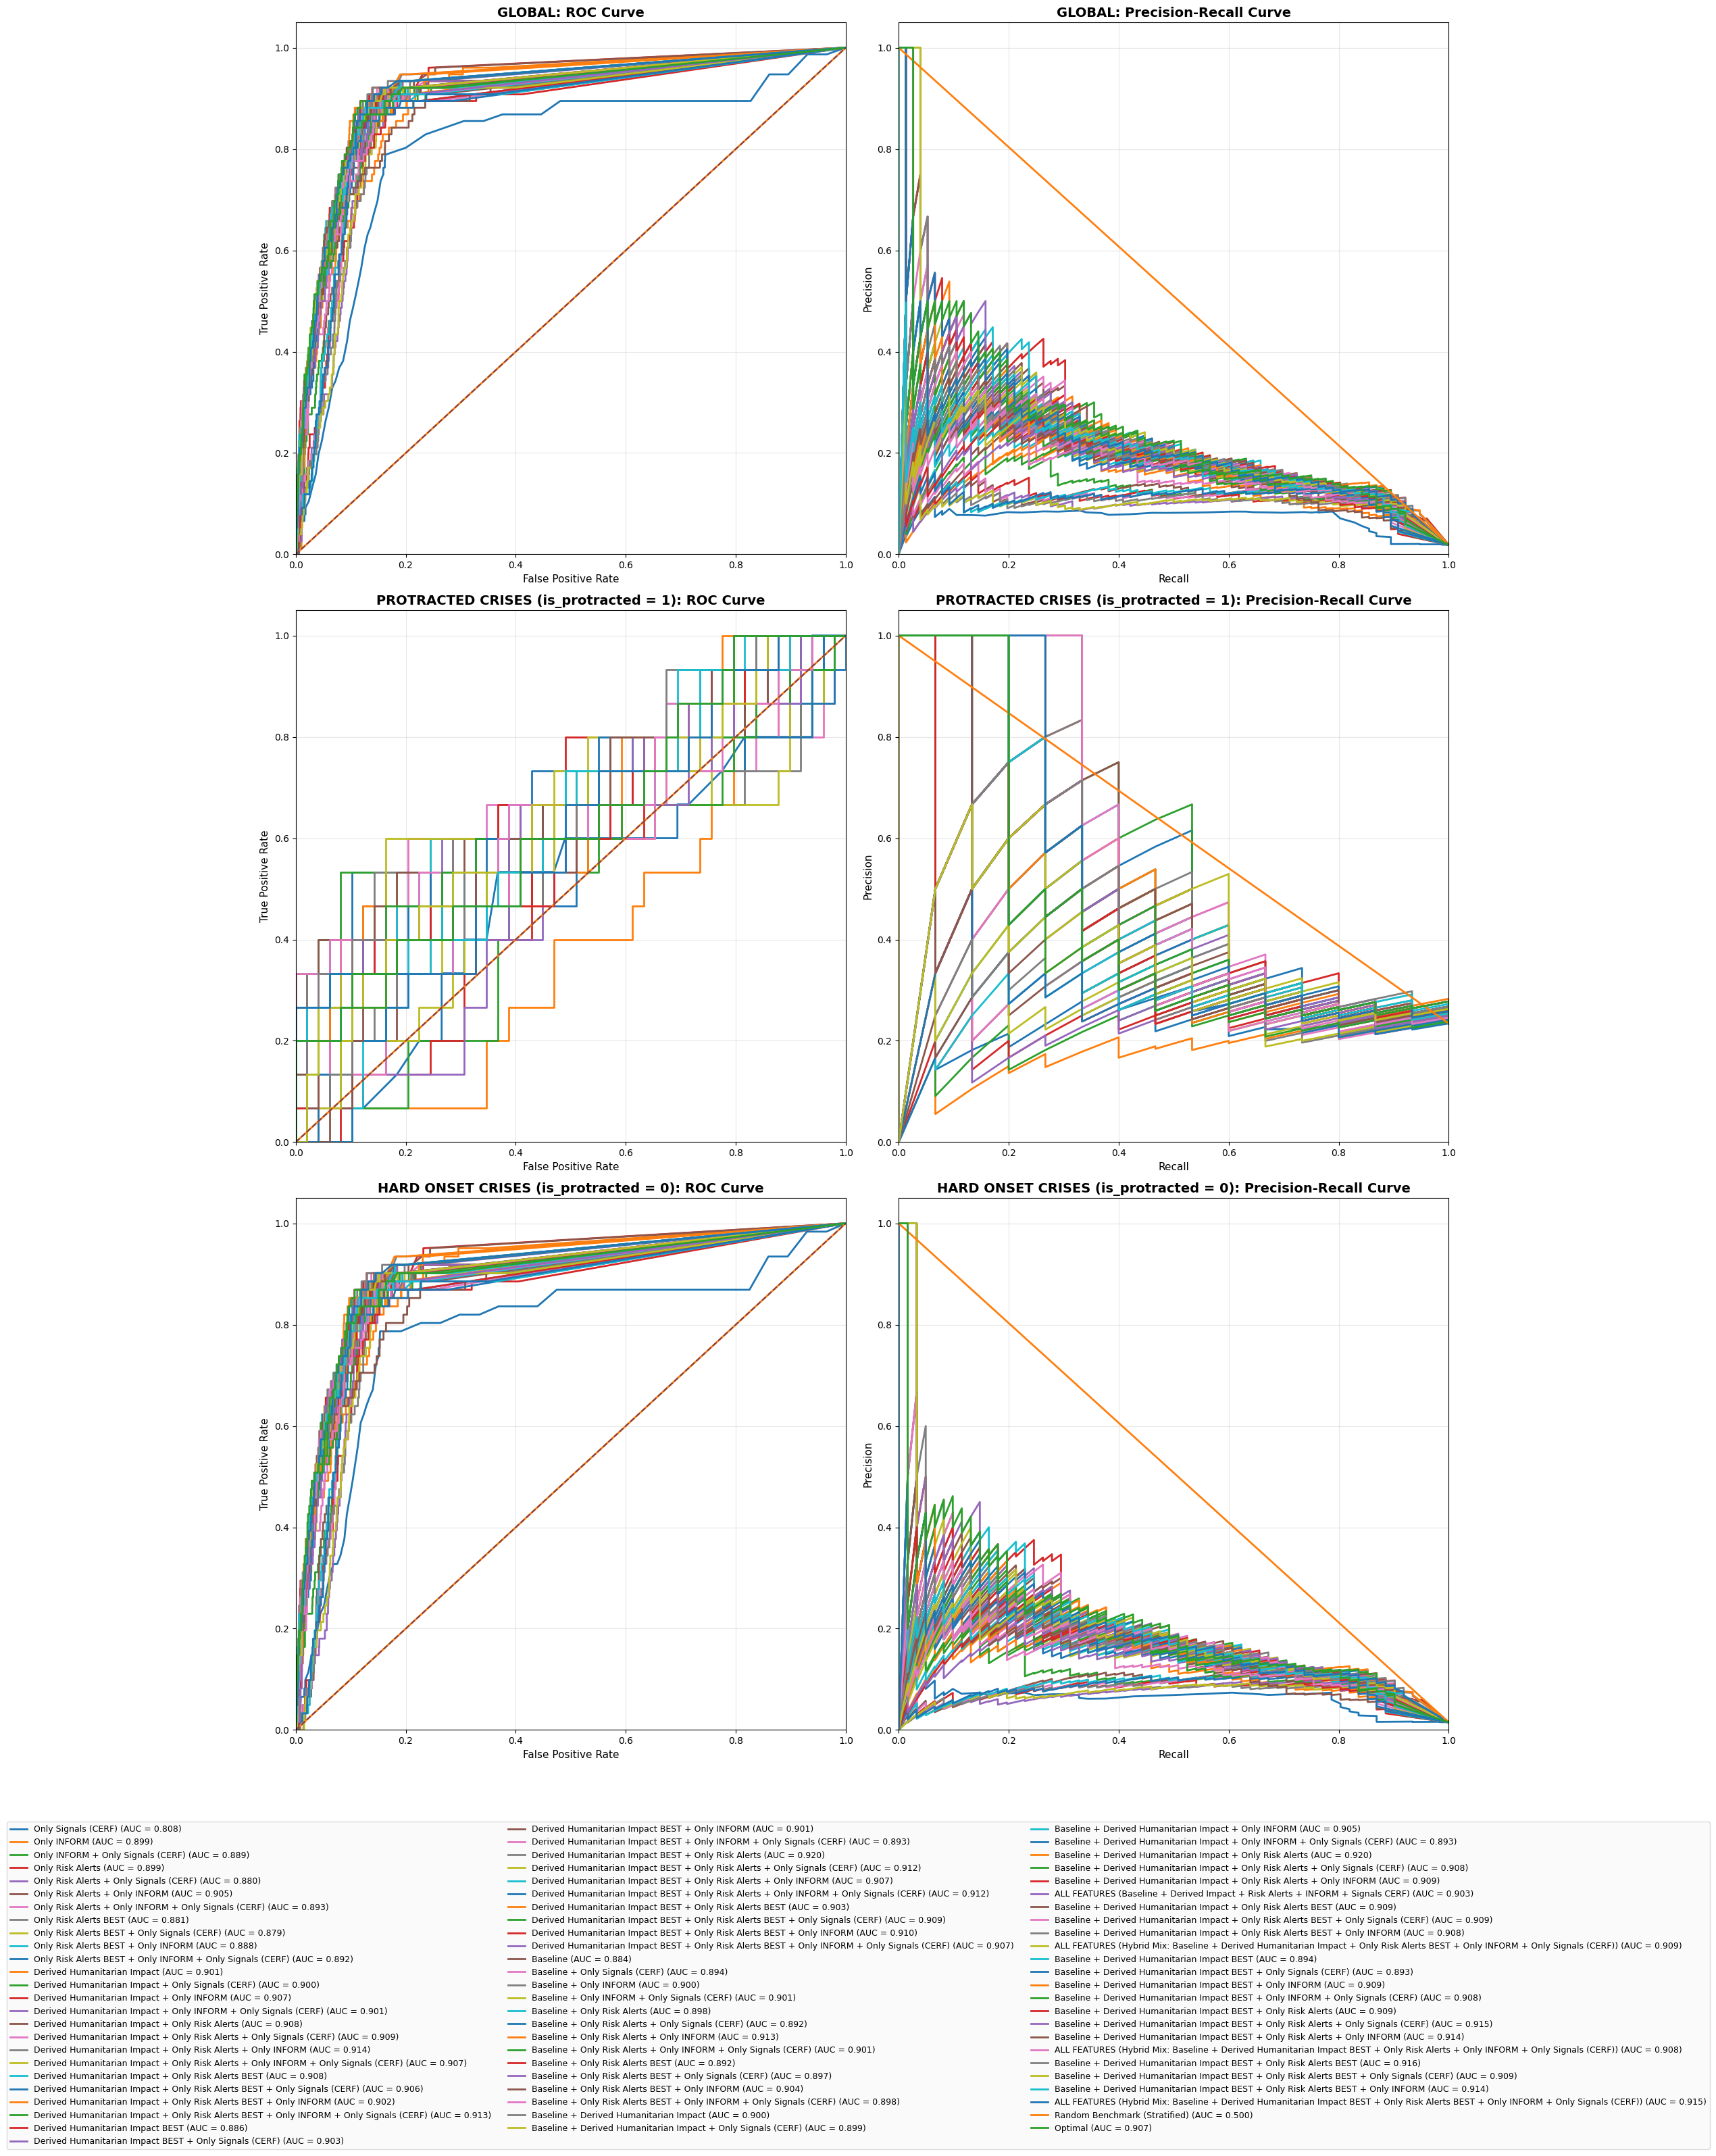


################################################################################################################################################################
                                                              FINAL RANKING (SORTED BY GLOBAL F1)                                                               
################################################################################################################################################################
                                                                                                                        Experiment   Thr  Glob F1  Glob P  Glob R  Glob AUC  Pro F1  Pro P  Pro R  Pro AUC  Hard F1  Hard P  Hard R  Hard AUC  Feats
                                                                                         Derived Humanitarian Impact + Only INFORM 0.791    0.338   0.383   0.303     0.907   0.435  0.625  0.333    0.656    0.319   0.346   0.295     0.898     35
                          

In [6]:
ruta_parquet = "../data_clean/final_data.parquet" 
df_original = pd.read_parquet(ruta_parquet)

if 'iso3' not in df_original.columns:
    df_original = df_original.reset_index()
if 'month' in df_original.columns:
    df_original['month'] = pd.to_datetime(df_original['month'], errors='coerce')


evaluate_experiments(
    plots_filter=models, 
    df_master=df_original,
    threshold_05=False, 
    experiments_map=experiments_map
)

### 2. CHOOSING THE FINAL MODEL (FINAL GROUP OF FEATURES)

We have decided that our final model is the one containing the following features:

In [ ]:
FINAL_FEATURES = []
TARGET_COL = 'target_2m'

Before stablishing the final model, we will do some hyperparameter tunning to see if we can improve the model:

In [4]:
df = pd.read_parquet("../data_clean/final_data.parquet")

In [ ]:
# Data Preparation 
def prepare_final_data(df, features_to_use, target_col='target_2m'):
    df_temp = df.copy()
    
    last_2_months_mask = df_temp.groupby('iso3').cumcount(ascending=False) < 2
    df_temp[target_col] = df_temp[target_col].astype(float)
    df_temp.loc[last_2_months_mask, target_col] = np.nan

    df_model = df_temp[features_to_use + [target_col, 'is_protracted']].dropna()
    
    X = df_model[features_to_use]
    y = df_model[target_col]
    subgroups = df_model['is_protracted'] 
    
    return X, y, subgroups


X, y, subgroups = prepare_final_data(df, FINAL_FEATURES, TARGET_COL)
periods = X.index.get_level_values('month')


panel_split = PanelSplit(periods=periods, n_splits=24, test_size=1, gap=1)
cv_splits = list(panel_split.split(X))

# HYPERPARAMETER TUNING 
print("Starting Hyperparameter Tuning...")

# Define the hyperparameter search space
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Base model for RandomizedSearchCV
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# Búsqueda aleatoria (más eficiente que GridSearchCV) optimizando el F1-Score
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,           
    scoring='f1',        # Optimize for the minority class directly
    cv=cv_splits,        # Using the PanelSplit temporal cross-validation
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X, y)
best_params = random_search.best_params_

print(f"Best Parameters:\n{best_params}\n")

# Validation with the best hyperparameters
print("Evaluating the model with the optimal parameters...")

# Instanciamos el modelo con los hiperparámetros ganadores
clf_cv = RandomForestClassifier(**best_params, class_weight='balanced', random_state=42, n_jobs=-1)

all_y_true, all_y_prob, all_iso3, all_months, all_subgroups = [], [], [], [], []

for train_idx, test_idx in cv_splits:
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    clf_cv.fit(X_train, y_train)
    probs = clf_cv.predict_proba(X_test)[:, 1]
    
    all_y_true.extend(y_test.values)
    all_y_prob.extend(probs)
    all_iso3.extend(X_test.index.get_level_values('iso3'))
    all_months.extend(X_test.index.get_level_values('month'))
    all_subgroups.extend(subgroups.iloc[test_idx].values)

df_eval = pd.DataFrame({
    'iso3': all_iso3,
    'month': all_months,
    'y_true': all_y_true,
    'y_prob': all_y_prob,
    'is_protracted': all_subgroups
})

# Compute the optimal threshold based on F1 score
precisions, recalls, thresholds = precision_recall_curve(df_eval['y_true'], df_eval['y_prob'])
f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls), out=np.zeros_like(precisions), where=(precisions + recalls) != 0)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

# Asign predictions based on the best threshold
df_eval['y_pred'] = (df_eval['y_prob'] >= best_threshold).astype(int)
print(f"Best threshold: {best_threshold:.4f}")

# Training the final model with 100% of the data for the SHAP values and the feature importance analysis
print("\n Training final model with 100% of the data...")

model_final = RandomForestClassifier(**best_params, class_weight='balanced', random_state=42, n_jobs=-1)
model_final.fit(X, y)

print("Final model trained successfully on 100% of the data.")


🚀 Entrenando modelo final con el 100% de los datos...
✅ Modelo final entrenado.


### 3. EVALUATING THE FINAL MODEL

#### 3.1 METRICS EVALUATION

In [ ]:
def print_subgroup_metrics(df, thr):
    print(f" Umbral Óptimo Aplicado: {thr:.3f}\n" + "-"*50)
    
    subsets = {
        'GLOBAL': df,
        'PROTRACTED (is_protracted = 1)': df[df['is_protracted'] == 1],
        'HARD ONSET (is_protracted = 0)': df[df['is_protracted'] == 0]
    }
    
    for name, sub_df in subsets.items():
        if len(sub_df) == 0: continue
        y_t = sub_df['y_true']
        y_p = sub_df['y_pred']
        y_prob = sub_df['y_prob']
        
        f1 = f1_score(y_t, y_p, zero_division=0)
        prec = precision_score(y_t, y_p, zero_division=0)
        rec = recall_score(y_t, y_p, zero_division=0)
        auc = roc_auc_score(y_t, y_prob) if len(np.unique(y_t)) > 1 else np.nan
        
        print(f"{name}:")
        print(f"   F1-Score: {f1:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | AUC: {auc:.3f}\n")

print_subgroup_metrics(df_eval, best_threshold)

 Umbral Óptimo Aplicado: 0.800
--------------------------------------------------
📊 GLOBAL:
   F1-Score: 0.329 | Precision: 0.317 | Recall: 0.342 | AUC: 0.907

📊 PROTRACTED (is_protracted = 1):
   F1-Score: 0.388 | Precision: 0.329 | Recall: 0.473 | AUC: 0.723

📊 HARD ONSET (is_protracted = 0):
   F1-Score: 0.000 | Precision: 0.000 | Recall: 0.000 | AUC: 0.811



#### 3.2 FEATURE IMPORTANCE AND SHAP VALUES

In [ ]:
df_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_final.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Feature importance:")
display(df_importance)

🏆 IMPORTANCIA DE LAS VARIABLES:


,feature,importance
7,logfat_risk_12,0.186530
13,logfat_risk_3,0.185845
0,disp_6m_avg,0.163136
2,fatalities,0.083654
1,rolling_3m_displacements,0.065614
6,disp_3m_avg,0.059562
4,VU,0.047071
5,INFORM,0.046504
3,HA,0.044459
8,lethality_rate,0.034263


Calculando SHAP values...
Formato nuevo de SHAP detectado (Matriz 3D).
Generando el gráfico Summary Plot...


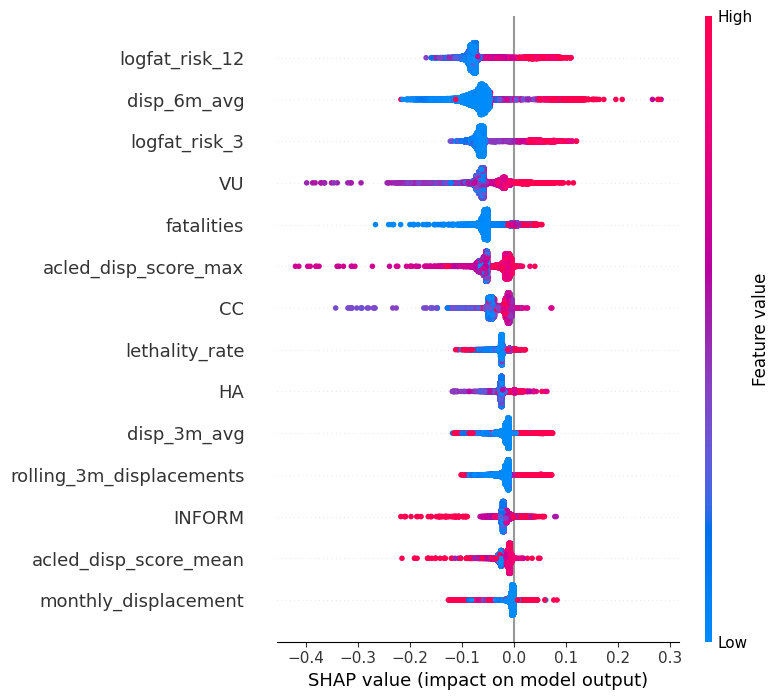

In [ ]:
explainer = shap.TreeExplainer(model_final)

# Compute the SHAP values for your matrix X
print("Computing SHAP values...")
shap_values = explainer.shap_values(X)

# Extract the positive class (1) safely
if isinstance(shap_values, list):
    print("Old SHAP format detected (List of arrays).")
    shap_values_positiva = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    print("New SHAP format detected (3D Array).")
    shap_values_positiva = shap_values[:, :, 1]
else:
    print("Old 2D format detected.")
    shap_values_positiva = shap_values

# Plotting the Summary Plot 
print("Generating Summary Plot...")
shap.summary_plot(shap_values_positiva, X)

#### 3.3 SHOWING EXAMPLES OF THE RESULTS

In [ ]:
print("FALSE POSITIVES:")
print(len(df_eval[df_eval['y_pred'] == 1]))

print("FALSE NEGATIVES:")
print(len(df_eval[(df_eval['y_pred'] == 0) & (df_eval['y_true'] == 1)]))

print("\n\n================ METRICS REPORT ================\n")
print(classification_report(df_eval['y_true'], df_eval['y_pred']))

FALSAS ALARMAS O ACIERTOS CRÍTICOS:
82
🚨 CRISIS NO DETECTADAS (Falsos Negativos):
50
================ MATRIZ DE CONFUSIÓN ================

Predicción (y_pred)     0   1
Realidad (y_true)            
0.0                  3928  56
1.0                    50  26


================ REPORTE DE MÉTRICAS ================

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      3984
         1.0       0.32      0.34      0.33        76

    accuracy                           0.97      4060
   macro avg       0.65      0.66      0.66      4060
weighted avg       0.97      0.97      0.97      4060



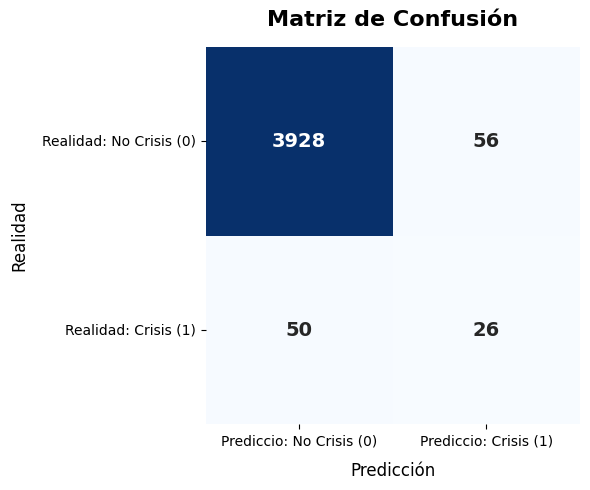

In [ ]:
# Comput the confusion matrix
cm = confusion_matrix(df_eval['y_true'], df_eval['y_pred'])


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Prediction: No Crisis (0)', 'Prediction: Crisis (1)'],
            yticklabels=['Reality: No Crisis (0)', 'Reality: Crisis (1)'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Prediction', fontsize=12, labelpad=10)
plt.ylabel('Reality', fontsize=12, labelpad=10)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
df_eval.head()

,iso3,month,y_true,y_prob,is_protracted,y_pred
0,AFG,2024-03-01,0.0,0.218651,1,0
1,AGO,2024-03-01,0.0,0.000000,0,0
2,ALB,2024-03-01,0.0,0.000000,0,0
3,ARE,2024-03-01,0.0,0.000000,0,0
4,ARG,2024-03-01,0.0,0.000000,0,0


In [12]:
df.head()

risk_3   risk_12  logfat_risk_3  logfat_risk_12  INFORM  \
iso3 month                                                                   
AFG  2018-01-01  0.999608  1.000000       8.331437        9.280007     7.8   
     2018-02-01  0.996514  1.000000       8.295601        9.393767     7.8   
     2018-03-01  0.998218  1.000000       8.339758        9.346226     7.8   
     2018-04-01  0.995082  0.999815       8.383570        9.414723     7.8   
     2018-05-01  0.991237  0.998947       8.342653        9.481498     7.7   

                  VU   CC   HA  fatalities  event_count  ...  \
iso3 month                                               ...   
AFG  2018-01-01  7.1  7.7  8.8      2822.0       1145.0  ...   
     2018-02-01  7.1  7.7  8.8      1829.0        920.0  ...   
     2018-03-01  7.1  7.7  8.8      2286.0        976.0  ...   
     2018-04-01  7.1  7.7  8.8      2794.0       1245.0  ...   
     2018-05-01  7.1  7.5  8.7      4264.0       1482.0  ...   

                INFORM_high_last_5m  is_protracted  p_sig1  p_sig2  p_sig3  \
iso3 month                                                                   
AFG  2018-01-01                   1              0       0       0       0   
     2018-02-01                   1              0       0       0       0   
     2018-03-01                   1              0       0       0       0   
     2018-04-01                   1              0       0       0       0   
     2018-05-01                   1              0       0       0       0   

                 protracted_signal  h_sig1  h_sig2  hard_onset_signal  \
iso3 month                                                              
AFG  2018-01-01                  0       0       0                  0   
     2018-02-01                  0       0       0                  0   
     2018-03-01                  0       0       0                  0   
     2018-04-01                  0       0       0                  0   
     2018-05-01                  0       0       0                  0   

                 early_signal  
iso3 month                     
AFG  2018-01-01             0  
     2018-02-01             0  
     2018-03-01             0  
     2018-04-01             0  
     2018-05-01             0  

[5 rows x 96 columns]

In [27]:
import pandas as pd

# 1. Asegurarnos de que las fechas tienen formato datetime
df_reset = df.reset_index().copy()
df_reset['month'] = pd.to_datetime(df_reset['month'])
df_eval['month'] = pd.to_datetime(df_eval['month'])

# ====================================================================
# EL CAMBIO: LÍMITES MARCADOS ESTRICTAMENTE POR EL TEST (df_eval)
# ====================================================================
min_month = df_eval['month'].min()
max_month = df_eval['month'].max()

# 3. Crear el "Esqueleto" temporal perfecto SOLO para la ventana de test
all_months_test = pd.date_range(start=min_month, end=max_month, freq='MS')

# Solo nos interesan los países que realmente entraron en la evaluación
all_countries_test = df_eval['iso3'].unique() 

esqueleto = pd.MultiIndex.from_product(
    [all_countries_test, all_months_test], 
    names=['iso3', 'month']
).to_frame(index=False)

# 4. Pegar los datos reales (df) a este esqueleto corto
# Esto rescata las variables (fatalities, etc) para los meses "borrados" en ese rango temporal
df_base = pd.merge(esqueleto, df_reset, on=['iso3', 'month'], how='left')

# 5. Pegar las predicciones (df_eval) al final
df_complete = pd.merge(df_base, df_eval, on=['iso3', 'month'], how='left')

print(f"Rango del gráfico: {min_month.strftime('%Y-%m')} hasta {max_month.strftime('%Y-%m')}")
print(f"Dimensiones finales (solo periodo de test, sin huecos): {df_complete.shape}")

Rango del gráfico: 2024-03 hasta 2026-02
Dimensiones finales (solo periodo de test, sin huecos): (4224, 102)


In [ ]:
def plot_country(country):
    country_df = df_complete[df_complete['iso3'] == country].sort_values('month').copy()
    
    # Normalize all variables to 0-1
    for col in ['fatalities', 'monthly_displacement', 'event_count']:
        max_val = country_df[col].max()
        country_df[col + '_norm'] = country_df[col] / max_val if max_val > 0 else 0

    fig, ax1 = plt.subplots(figsize=(14, 6))
    fig.suptitle(f'{country} — Multi-Signal Overview (normalized)', fontsize=13)
    
    ax1.plot(country_df['month'], country_df['fatalities_norm'],
             color='firebrick', linewidth=1.5, label='Fatalities (norm)')
    ax1.plot(country_df['month'], country_df['monthly_displacement_norm'],
             color='purple', linewidth=1.5, label='Displacement (norm)')
    ax1.plot(country_df['month'], country_df['event_count_norm'],
             color='gray', linewidth=1, alpha=0.7, label='Event count (norm)')
    ax1.plot(country_df['month'], country_df['risk_3'],
             color='black', linewidth=1.5, linestyle='--', label='Risk_3')
    ax1.plot(country_df['month'], country_df['INFORM'] / 10,
             color='steelblue', linewidth=1.5, linestyle=':', label='INFORM (norm)')
    

    # True Positives (TP: pred=1 i true=1) -> Green dashed
    true_pos = country_df[(country_df['y_pred'] == 1) & (country_df['y_true'] == 1)]['month']
    for month in true_pos:
        ax1.axvline(x=month, color='green', alpha=0.8, linewidth=2, linestyle='--', label='TP (Encert Crític)')

    # False Positives (FP: pred=1 i true=0) -> Orange dashed
    false_pos = country_df[(country_df['y_pred'] == 1) & (country_df['y_true'] == 0)]['month']
    for month in false_pos:
        ax1.axvline(x=month, color='darkorange', alpha=0.8, linewidth=2, linestyle='--', label='FP (Falsa Alarma)')

    # False Negatives (FN: pred=0 i true=1) -> Red dashed
    false_neg = country_df[(country_df['y_pred'] == 0) & (country_df['y_true'] == 1)]['month']
    for month in false_neg:
        ax1.axvline(x=month, color='red', alpha=0.8, linewidth=2, linestyle='--', label='FN (Crisi no detectada)')

    ax1.set_ylim(0, 1.1)
    ax1.set_ylabel('Normalized value (0-1)')
    ax1.set_xlabel('Month')

    # Allocation-eligible 
    eligible = country_df[country_df['allocation-eligible'] == 1]['month']
    for month in eligible:
        ax1.axvline(x=month, color='red', alpha=0.1, linewidth=15, label='Allocation Eligible')

    # HDX alerts
    hdx_medium = country_df[country_df['hdx_alert_Medium concern'] == True]['month']
    hdx_high = country_df[country_df['hdx_alert_High concern'] == True]['month']
    ax1.scatter(hdx_medium, [1.05]*len(hdx_medium), color='orange', s=60, zorder=5, label='HDX Medium')
    ax1.scatter(hdx_high, [1.05]*len(hdx_high), color='red', s=60, zorder=5, label='HDX High')

    # Delete duplicate legend entries
    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax1.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=8)
    
    plt.tight_layout()
    plt.show()

countries = sorted(df_complete['iso3'].unique().tolist())
dropdown = widgets.Dropdown(options=countries, value='AFG', description='Country:')
widgets.interact(plot_country, country=dropdown)

interactive(children=(Dropdown(description='Country:', options=('AFG', 'AGO', 'ALB', 'ARE', 'ARG', 'ARM', 'AUS…

<function __main__.plot_country(country)>

FALTA LA GRAFICA COMPARANDOLO CON LO DE LAS CERF ALLOCATIONS QUE ESTAN EN CLEAN DATA EN CERF_CLEAN!

#### 3.4 ROBUSTNESS CHECKS